In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
import rasterio
from rasterio.windows import Window
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
# import geemap
# import geemap.foliumap as geemap

In [3]:
DATA_DIR = "../Data"

ncr_path = os.path.join(DATA_DIR, "delhi_ncr_region.geojson")
airshed_path= os.path.join(DATA_DIR, "delhi_airshed.geojson")

# ncr = gpd.read_file(ncr_path)
# airshed = gpd.read_file(airshed_path)

delhi_ncr = gpd.read_file(ncr_path)

print("CRS:", delhi_ncr.crs)
print("Bounds:", delhi_ncr.total_bounds)
print("total regions are",len(delhi_ncr))
delhi_ncr.head()

CRS: EPSG:4326
Bounds: [75.47339618 26.70606228 78.47747708 29.99343912]
total regions are 30


,geometry
0,"POLYGON ((76.85108 28.22115, 76.85219 28.22098..."
1,"POLYGON ((77.15903 29.29436, 77.15999 29.29427..."
2,"MULTIPOLYGON (((77.07565 27.27704, 77.07819 27..."
3,"POLYGON ((77.97073 28.71104, 77.97089 28.71096..."
4,"POLYGON ((77.2143 28.78524, 77.21521 28.78514,..."


In [4]:
delhi_ncr_utm = delhi_ncr.to_crs(epsg=32644)

print("Converted CRS:", delhi_ncr_utm.crs)
delhi_ncr_utm.head()

Converted CRS: EPSG:32644


,geometry
0,"POLYGON ((92705.299 3128681.971, 92814.275 312..."
1,"POLYGON ((126807.651 3246725.534, 126900.778 3..."
2,"MULTIPOLYGON (((111425.99 3023225.84, 111674.0..."
3,"POLYGON ((204057.708 3179732.309, 204073.282 3..."
4,"POLYGON ((130368.065 3190077.582, 130456.57 31..."


In [25]:
# # airshed = gpd.read_file(airshed)

# print("CRS:", airshed.crs)
# print("Bounds:", airshed.total_bounds)
# print("total regions are",len(airshed))
# airshed.head()

In [6]:
def create_grid(gdf, grid_size=60000):
    xmin, ymin, xmax, ymax = gdf.total_bounds

    cells = []
    for x in np.arange(xmin, xmax, grid_size):
        for y in np.arange(ymin, ymax, grid_size):
            cells.append(box(x, y, x+grid_size, y+grid_size))

    grid = gpd.GeoDataFrame({"geometry": cells}, crs=gdf.crs)

    # keep only intersecting cells
    # grid = gpd.overlay(grid, gdf, how="intersection")
    return grid

In [7]:
grid = create_grid(delhi_ncr_utm, 60000)

print("Number of grid cells:", len(grid))

Number of grid cells: 35


In [8]:
for i in range(min(10, len(grid))):
    cell = grid.iloc[i].geometry
    minx, miny, maxx, maxy = cell.bounds
    w = (maxx - minx)/1000
    h = (maxy - miny)/1000
    print(f"Cell {i}: {w:.2f} km × {h:.2f} km")

Cell 0: 60.00 km × 60.00 km
Cell 1: 60.00 km × 60.00 km
Cell 2: 60.00 km × 60.00 km
Cell 3: 60.00 km × 60.00 km
Cell 4: 60.00 km × 60.00 km
Cell 5: 60.00 km × 60.00 km
Cell 6: 60.00 km × 60.00 km
Cell 7: 60.00 km × 60.00 km
Cell 8: 60.00 km × 60.00 km
Cell 9: 60.00 km × 60.00 km


In [9]:
# pick first grid cell
cell = grid.iloc[0].geometry

minx, miny, maxx, maxy = cell.bounds

width = maxx - minx
height = maxy - miny

print("Width (m):", width)
print("Height (m):", height)

print("Width (km):", width/1000)
print("Height (km):", height/1000)

Width (m): 60000.0
Height (m): 60000.0
Width (km): 60.0
Height (km): 60.0


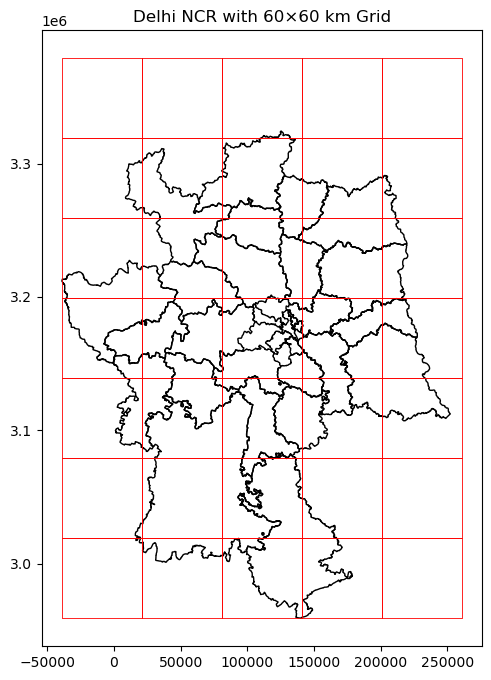

In [10]:
fig, ax = plt.subplots(figsize=(8,8))

delhi_ncr_utm.boundary.plot(ax=ax, color="black", linewidth=1)
grid.boundary.plot(ax=ax, color="red", linewidth=0.6)

plt.title("Delhi NCR with 60×60 km Grid")
# plt.savefig("../Visualizations/delhi_ncr_grid.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
import os
import pandas as pd

RGB_DIR = os.path.join("../Data", "rgb")

image_files = [
    f for f in os.listdir(RGB_DIR)
    if f.endswith(".png")
]

print("Total images BEFORE filtering:", len(image_files))
image_files[:5]

Total images BEFORE filtering: 9216


['28.2056_76.8558.png',
 '28.2056_76.8646.png',
 '28.2056_76.8734.png',
 '28.2056_76.8822.png',
 '28.2056_76.8910.png']

In [14]:
records = []

for fname in image_files:
    name = fname.replace(".png", "")
    
    try:
        lat_str, lon_str = name.split("_")
        lat = float(lat_str)
        lon = float(lon_str)
        
        records.append({
            "image_name": fname,
            "lat": lat,
            "lon": lon
        })
    except:
        continue  # skip bad files

meta = pd.DataFrame(records)

print("Parsed images:", len(meta))
meta.head()

Parsed images: 9216


,image_name,lat,lon
0,28.2056_76.8558.png,28.2056,76.8558
1,28.2056_76.8646.png,28.2056,76.8646
2,28.2056_76.8734.png,28.2056,76.8734
3,28.2056_76.8822.png,28.2056,76.8822
4,28.2056_76.8910.png,28.2056,76.8910


In [15]:
import geopandas as gpd
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(meta.lon, meta.lat)]
geometry[:5]

[<POINT (76.856 28.206)>,
 <POINT (76.865 28.206)>,
 <POINT (76.873 28.206)>,
 <POINT (76.882 28.206)>,
 <POINT (76.891 28.206)>]

In [16]:
points = gpd.GeoDataFrame(
    meta,
    geometry=geometry,
    crs="EPSG:4326"
)

points_utm = points.to_crs(epsg=32644)
points_utm.head()

,image_name,lat,lon,geometry
0,28.2056_76.8558.png,28.2056,76.8558,POINT (93110.183 3126940.842)
1,28.2056_76.8646.png,28.2056,76.8646,POINT (93975.03 3126911.256)
2,28.2056_76.8734.png,28.2056,76.8734,POINT (94839.871 3126881.733)
3,28.2056_76.8822.png,28.2056,76.8822,POINT (95704.707 3126852.274)
4,28.2056_76.8910.png,28.2056,76.8910,POINT (96569.538 3126822.877)


In [17]:
filtered = gpd.sjoin(
    points_utm,
    delhi_ncr_utm,
    predicate="within"
)

print("Total images AFTER filtering:", len(filtered))

Total images AFTER filtering: 8015


In [22]:
filtered.to_csv("../Dataset/filtered_images.csv", index=False)
print ("data is saved to filtered_images.csv")

data is saved to filtered_images.csv


In [23]:
Deta_path="../Dataset/filtered_images.csv"
df = pd.read_csv(Deta_path)
print("Parsed images:", len(df))
df.head()

Parsed images: 8015


,image_name,lat,lon,geometry,index_right
0,28.2056_76.8558.png,28.2056,76.8558,POINT (93110.1832241413 3126940.842381583),0
1,28.2056_76.8646.png,28.2056,76.8646,POINT (93975.02981162816 3126911.2561693112),0
2,28.2056_76.8734.png,28.2056,76.8734,POINT (94839.87106457737 3126881.7332521495),23
3,28.2056_76.8822.png,28.2056,76.8822,POINT (95704.70699433371 3126852.2736275145),23
4,28.2056_76.8910.png,28.2056,76.8910,POINT (96569.53761225089 3126822.87729283),23


In [20]:
print("Number of NCR polygons:", len(delhi_ncr_utm))
print(delhi_ncr_utm.index)

Number of NCR polygons: 30
RangeIndex(start=0, stop=30, step=1)


In [26]:
print(filtered["index_right"].value_counts().head(30))

index_right
5     1363
6     1128
18    1110
17     985
28     819
1      612
8      297
23     297
19     277
10     210
24     203
12     198
4      141
15     129
7      123
11      48
13      45
3       14
27       7
0        7
26       2
Name: count, dtype: int64
